# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Melvryan Lee Le Yang



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor


from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

from scipy.stats import randint, uniform

from sklearn.model_selection import RandomizedSearchCV

import joblib

# 1. Business Understanding
Goal: Predict insurance price for a person in US

US is known to have a medical bills. Having insurance makes it easier to pay off the medical fees if an accident does happen. As it is better to be safe then sorry, having an insurance is important. However, the price of the insurance can be difficult to afford because it can defer from person to person and may be higher or lower depending on how the insurance provider deems the person is high risk or low risk. As the price may change, it may be difficult to predict how much it costs to purchase one. This makes this machine learning model useful as it will help estimate
 the cost of the insurance from a person based on their own conditions.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
#https://www.kaggle.com/datasets/mirichoi0218/insurance/data
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


Sex, smoker and region are string values so they need to be one-hot-encoded to be used in this model.


In [4]:
## Check for missing data
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

This shows that there is no missing values in the data

In [5]:
print(df.nunique())

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


The number of unique values in each feature was examined using df.nunique() to better understand the characteristics of the dataset.

The dataset contains a mix of categorical (sex, smoker, region) and numerical (age, bmi, children, charges) features.
The categorical variables will require One-Hot Encoding during the preprocessing stage before training the machine learning models.

In [6]:
df.duplicated().sum()

df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


This indicates that there is a potentially duplicated entry. It could be a different person with the exact same conditions but since there is no way to identify if these are different entries, it is best to remove in the case it is duplicated as the chances that bmi is the exact same to the second decimal place and charges is the exact same to the fourth decimal place is unlikely.

During data preparation, remove the duplicated entry

In [7]:
## Describe data distribution
df.describe(include='all')



,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


 All colums have 1338 count which shows there is no missing values

 unique values for categorical values for sex and smoker are 2 and for region is 4.This shows that the machine should be able to predict based on region, gender and smoker status. 
 
 For this dataset, the majority of the data is non-smokers with 1064. This could mean there could be a bias in the data for non-smokers.

 There is about 676 male people in the dataset so that it is quite balanced on that aspect.

 The age of this ranges from 18 to 64 which means it represents adults across a wide range

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

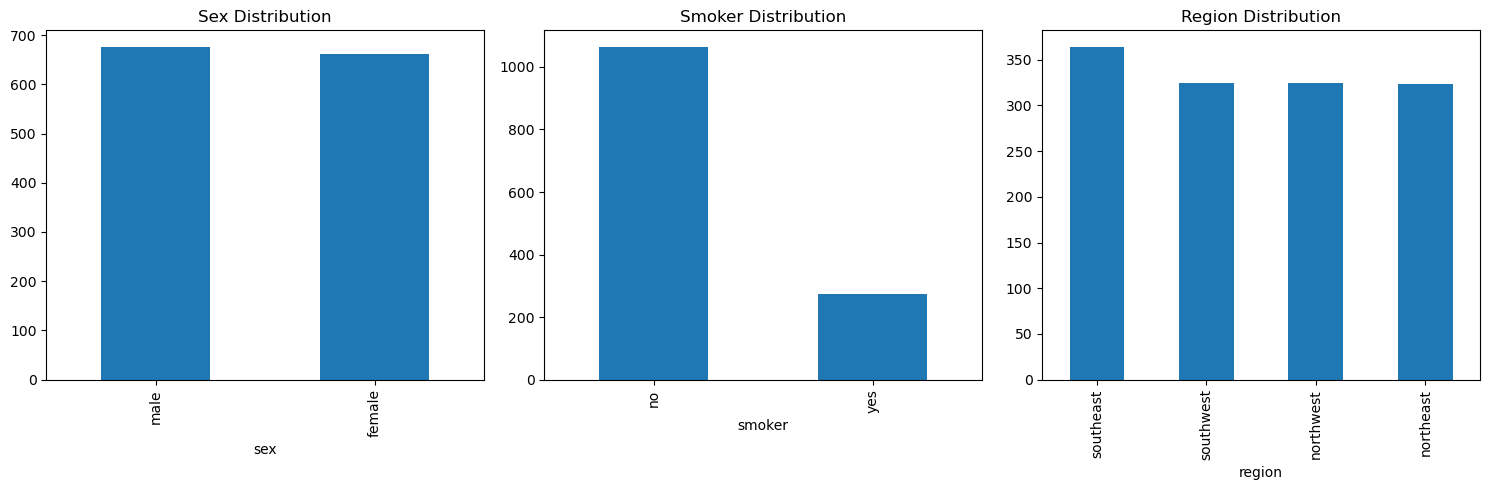

In [8]:
# plot a bar graph to show counts of each target

# Plot bar charts to show the count of each category for the categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15,5))

df["sex"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Sex Distribution")

df["smoker"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Smoker Distribution")

df["region"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Region Distribution")

plt.tight_layout()
plt.show()

The bar charts show the distribution of the categorical variables in the dataset.

Sex: The dataset is relatively balanced, with a similar number of male and female individuals. This suggests that neither gender is heavily overrepresented.

Smoker: Most individuals in the dataset are non-smokers, while smokers make up a much smaller proportion of the data. This indicates an imbalanced distribution for the smoker feature.

Region: The four geographical regions contain a similar number of records, although the southeast region has slightly more observations than the other regions. Overall, the regional distribution is fairly balanced.

### 2.3.1.2 Understanding distribution of features

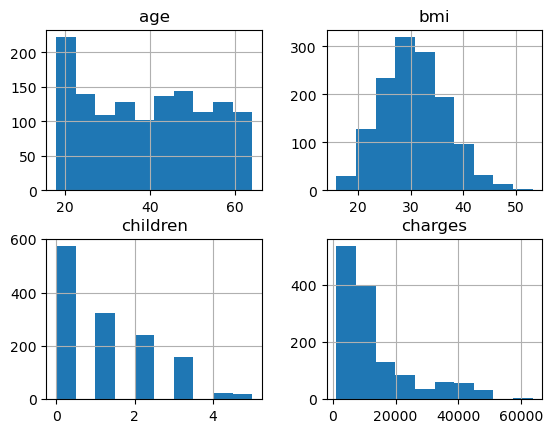

In [9]:
## Understanding distribution of target
df.hist()
plt.show()

The ages of individuals range from approximately 18 to 64 years old. The distribution is relatively even across the age groups, indicating that the dataset includes both younger and older adults.

BMI values are approximately normally distributed, with most individuals having a BMI between 25 and 35. A small number of observations have relatively high BMI values, which may represent potential outliers.

The majority of individuals have no children, while progressively fewer individuals have one or more children. This indicates that the distribution is positively skewed towards smaller family sizes.

Insurance charges are positively skewed. Most individuals incur relatively low medical insurance charges, while a small number of individuals have substantially higher charges. This suggests the presence of high-cost cases within the dataset.

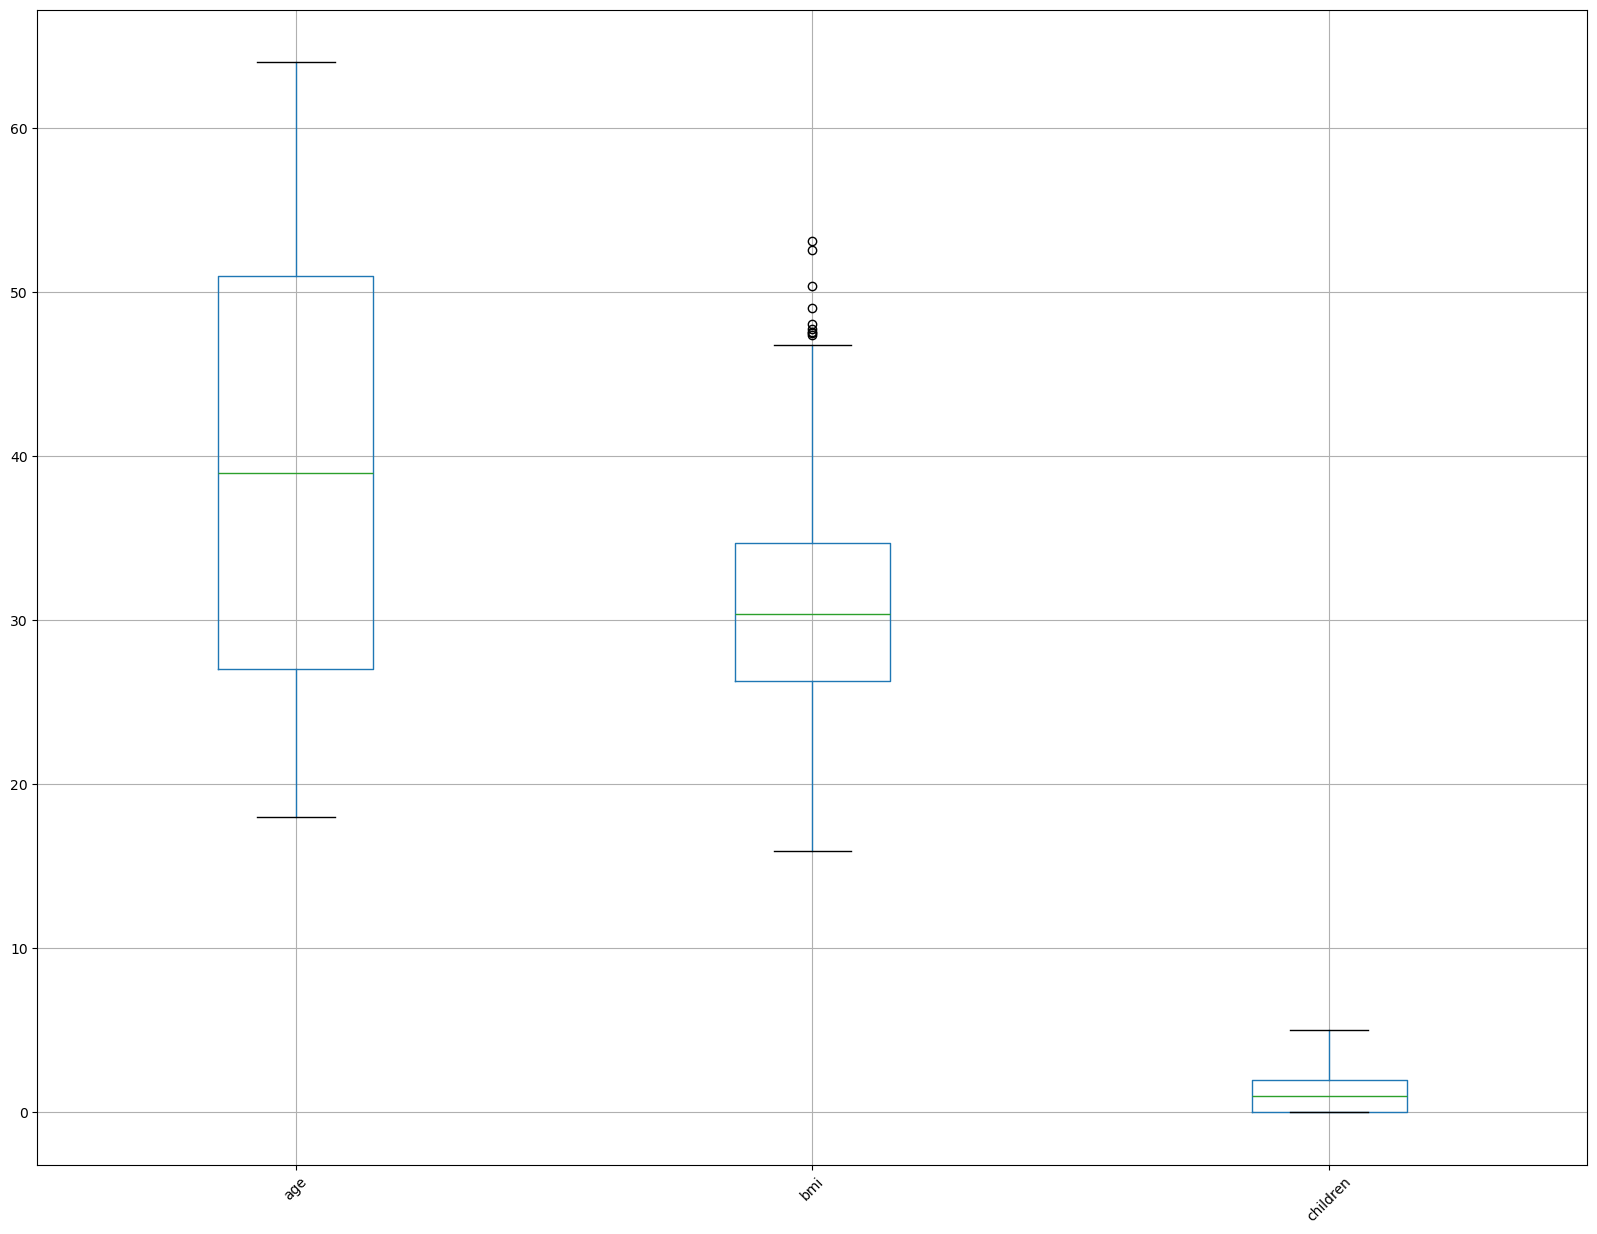

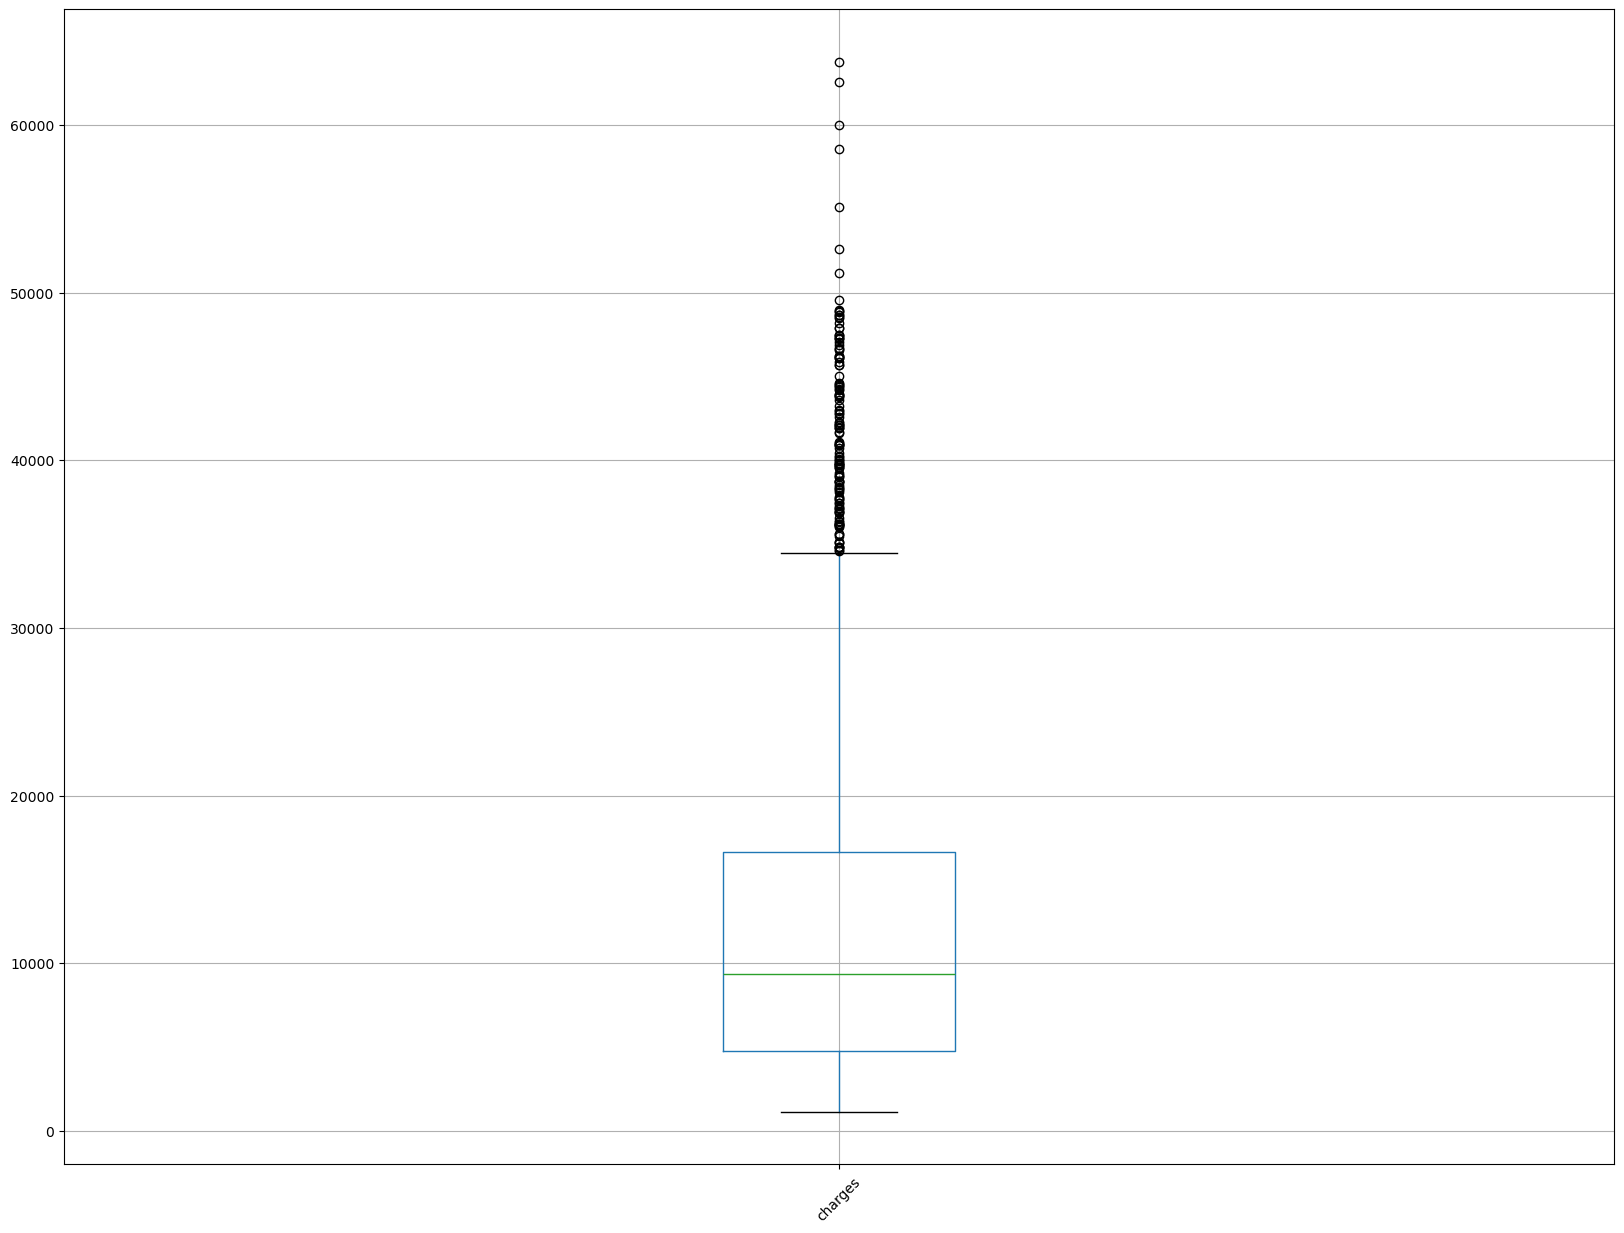

In [10]:
## Understanding distribution of features
no_charge = df.drop(columns=['charges'])
no_charge.boxplot(rot=45, figsize=(20, 15))
plt.show('no_charge')
charges = df[['charges']]
charges.boxplot(rot=45, figsize=(20, 15))
plt.show('charges')

The BMI boxplot indicates that most individuals have BMI values between approximately 26 and 35, with a median of around 30. Several high-value outliers are present above 47. These observations are likely to represent individuals with unusually high BMI rather than data entry errors. Therefore, they were retained for model training.

The BMI boxplot indicates that most individuals have BMI values between approximately 26 and 35, with a median of around 30. Several high-value outliers are present above 47. These observations are likely to represent individuals with unusually high BMI rather than data entry errors. Therefore, they were retained for model training.

The children variable ranges from 0 to 5, with the majority of individuals having between 0 and 2 children. No significant outliers are present in this feature.

The boxplot for insurance charges reveals a large number of high-value outliers, with some charges exceeding $60,000. This indicates that while most individuals incur relatively moderate insurance costs, a small proportion have substantially higher charges. These values are likely to represent genuine high-cost cases rather than errors and were therefore retained for model training. Retaining these observations enables the machine learning model to learn from real-world variations in insurance costs.

Overall, the boxplots show that the age and children variables do not contain significant outliers. The BMI and insurance charges variables contain several high-value outliers; however, these are likely to represent genuine observations rather than data errors. As the objective is to predict real insurance charges, these observations were retained instead of being removed.

### 2.3.2 Understanding relationship between variables

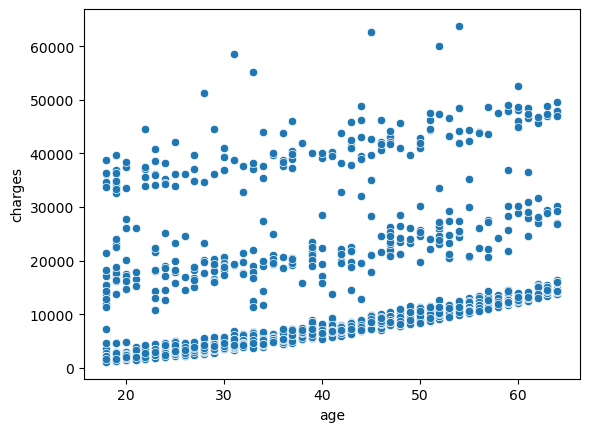

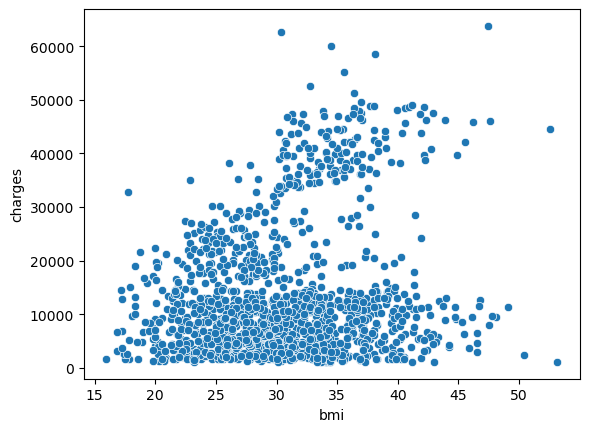

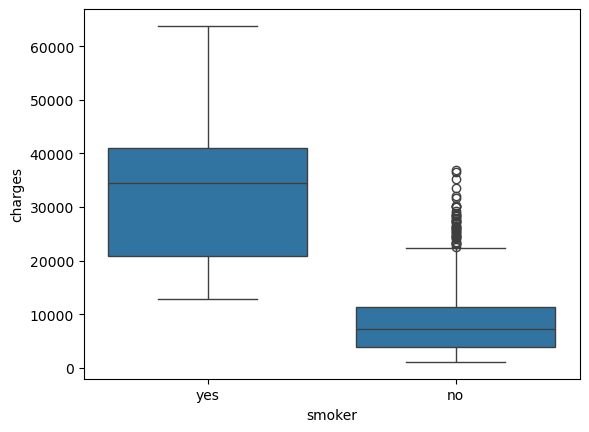

In [11]:
## Understanding relationship between variables
sns.scatterplot(data=df, x='age', y='charges')
plt.show()
sns.scatterplot(data=df, x='bmi', y='charges')
plt.show()
sns.boxplot(data=df, x='smoker', y='charges')
plt.show()

Age and Charges graph: The scatter plot shows a positive relationship between age and insurance charges. Older individuals generally incur higher insurance costs than younger individuals. However, there is considerable variation in charges at each age, suggesting that other factors, such as smoking status and BMI, also influence insurance costs.

Bmi and Charges Graph: The scatter plot indicates that individuals with higher BMI generally tend to have higher insurance charges. In particular, insurance charges increase noticeably for BMI values above approximately 30. However, the relationship is not perfectly linear, indicating that BMI interacts with other variables when determining insurance costs.

Smoker and Charges Graph: The boxplot shows a substantial difference in insurance charges between smokers and non-smokers. Smokers have a much higher median insurance charge and a wider spread of values than non-smokers. This suggests that smoking status is one of the strongest factors affecting insurance costs.

In [12]:
col_numeric = df.select_dtypes(include=['float', 'int']).columns

df_corr = df[col_numeric].corr()
df_corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


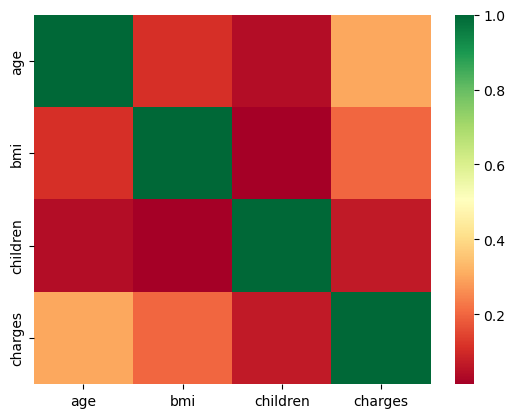

In [13]:
sns.heatmap(df_corr, cmap='RdYlGn')
plt.show()

The heatmap visualises the correlation between the numerical variables in the dataset. Age has the strongest positive correlation with insurance charges (0.299), followed by BMI (0.198), indicating that older individuals and those with higher BMI generally tend to have higher insurance charges. The number of children has a very weak correlation with charges (0.068), suggesting that it has little influence on insurance costs. Overall, the numerical variables have relatively weak correlations with each other, indicating that no single numerical feature alone strongly determines insurance charges.

# 3. Data Preparation

## 3.1 Data Cleaning

In [14]:
## Clean data

## Remove duplicates
df = df.drop_duplicates()

## One Hot Encoding
df = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

df

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


## 3.2 Train-Test Split

In [15]:
## Split data into train set and test set

X = df.drop("charges", axis=1)
y = df["charges"]    

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=200
)



# 4. Modelling

### 4.2 Train Model

In [16]:
## Initialise and train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


## Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=200)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

## Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(random_state=200)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)


# 5. Model Evaluation

In [17]:
## Evaluate model

# Linear Regression
print("Linear Regression")
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print()

print()

# Decision Tree
print("Decision Tree")
print("R²:", r2_score(y_test, dt_pred))
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("MSE:", mean_squared_error(y_test, dt_pred))
print("RMSE:", root_mean_squared_error(y_test, dt_pred))

print()

# Gradient Boosting
print("Gradient Boosting")
print("R²:", r2_score(y_test, gb_pred))
print("MAE:", mean_absolute_error(y_test, gb_pred))
print("MSE:", mean_squared_error(y_test, gb_pred))
print("RMSE:", root_mean_squared_error(y_test, gb_pred))

Linear Regression
R²: 0.7657345890124148
MAE: 4313.346524337451
MSE: 37637853.25385473
RMSE: 6134.969702765836


Decision Tree
R²: 0.7560870542156203
MAE: 2844.746011007463
MSE: 39187858.000233844
RMSE: 6260.020607013514

Gradient Boosting
R²: 0.8674210608801894
MAE: 2506.1845207119954
MSE: 21300569.44431977
RMSE: 4615.253995645285


The models were evaluated using four regression metrics: R², MAE, MSE, and RMSE.

R² (Coefficient of Determination) measures how well the model explains the variation in insurance charges. A higher R² indicates better predictive performance. (Shows how well the model explains the variation in insurance charges. This is the standard metric for comparing regression models.)

MAE (Mean Absolute Error) measures the average absolute difference between the predicted and actual charges. Lower MAE values indicate more accurate predictions. (Shows the average prediction error and is less sensitive to outliers. Since the dataset has many outliers in charges, MAE provides a realistic measure of typical error.)

MSE (Mean Squared Error) measures the average squared prediction error. Because errors are squared, larger prediction errors are penalized more heavily. (Penalizes large prediction errors and is measured in the same units as charges, making it easy to interpret.)

RMSE (Root Mean Squared Error) is the square root of MSE and is expressed in the same unit as the target variable (insurance charges), making it easier to interpret. Lower RMSE indicates better predictive performance.  (Mainly useful because RMSE is derived from it. It is less intuitive since the units are squared dollars.)

The evaluation results show that the Gradient Boosting model performs the best among the three models. It achieves the highest R² score (0.8674), meaning it explains approximately 86.7% of the variance in insurance charges. In addition, it has the lowest MAE (2506.18), lowest MSE (21,300,569.44), and lowest RMSE (4615.25). These results indicate that Gradient Boosting produces the most accurate predictions with the smallest prediction errors, and it was therefore selected as the final model for further tuning.

MAE (Mean Absolute Error) was selected as the primary evaluation metric because the insurance charges dataset contains several outliers. Unlike MSE and RMSE, MAE is less influenced by extreme values and therefore provides a more reliable measure of the model's typical prediction error. Since the objective of the project is to produce accurate predictions for insurance charges, MAE offers an interpretable measure of the average prediction error. This means that on average, the predicted result ranges from + or - the MAE value. In the context of insurance pricing, this means a predicted charge is typically accurate to within about $2,506.18 of the true value. This level of precision is meaningful for both the insurer, in estimating expected costs, and the customer, in understanding the reliability of the quoted estimate.

R² was used as a supporting metric because it measures how well the regression model explains the variation in insurance charges. A higher R² value indicates that the model captures a greater proportion of the variance in the target variable, making it useful for comparing the overall performance of different regression models.

In [18]:
##Test for overfitting and underfitting

##Linear Regression
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Linear Regression")
print("Training MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))
print("Training R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print()

# Decision Tree
train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

print("Decision Tree")
print("Training MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))
print("Training R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print()

# Gradient Boosting
train_pred = gb_model.predict(X_train)
test_pred = gb_model.predict(X_test)

print("Gradient Boosting")
print("Training MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))
print("Training R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print()

Linear Regression
Training MAE: 4147.7783685300665
Test MAE: 4313.346524337451
Training R²: 0.7455828961410085
Test R²: 0.7657345890124148

Decision Tree
Training MAE: 17.905869831618336
Test MAE: 2844.746011007463
Training R²: 0.998801268140757
Test R²: 0.7560870542156203

Gradient Boosting
Training MAE: 2033.528075036926
Test MAE: 2506.1845207119954
Training R²: 0.9045472354843829
Test R²: 0.8674210608801894



To determine whether the models were overfitting or underfitting, the MAE and R² scores on the training and test datasets were compared.

The models were evaluated using the Mean Absolute Error (MAE) as the primary metric, with R² used as a supporting metric to assess how well the models generalise from the training data to the test data.

Linear Regression achieved a training MAE of 4147.78 and a test MAE of 4313.35. The small increase in MAE, together with the similar training (0.7456) and test (0.7657) R² scores, indicates that the model generalises well and does not exhibit significant overfitting. However, its prediction errors remain relatively high.
Decision Tree achieved an extremely low training MAE of 17.91, but the test MAE increased substantially to 2844.75. Likewise, the training R² (0.9988) was much higher than the test R² (0.7561). This large difference indicates that the model has overfitted the training data and does not generalise well to unseen data.
Gradient Boosting achieved a training MAE of 2033.53 and a test MAE of 2506.18. The relatively small increase in MAE, together with the close training (0.9045) and test (0.8674) R² scores, indicates that the model generalises well with only slight overfitting.

Overall, although Linear Regression generalises well, it produces larger prediction errors. Decision Tree suffers from significant overfitting. Gradient Boosting provides the best balance between prediction accuracy and generalisation performance, and was therefore selected for hyperparameter tuning

## Iterative model development


In [19]:
## Hyper Parameter Tuning

##Params for RandomSearchCV

param_dist = {
    ##Three values for each hyperparameter
    "n_estimators": [25, 50, 100],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

##Randomized Search CV
random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=200),
    param_distributions=param_dist,
    n_iter=27,
    cv=5,
    scoring="neg_mean_absolute_error",
    random_state=200,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)
print("Best CV MAE:", -random_search.best_score_)

best_pred = random_search.predict(X_test)
print("MAE:", mean_absolute_error(y_test, best_pred))
print("Tuned R²:", r2_score(y_test, best_pred))



Best Parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}
Best CV MAE: 2536.849018011116
MAE: 2464.934484881061
Tuned R²: 0.8710771117971275


Hyperparameter Tuning

Hyperparameter tuning was performed on the Gradient Boosting Regressor using RandomizedSearchCV with 5-fold cross-validation. Mean Absolute Error (MAE) was selected as the evaluation metric because it is the primary metric for this project and is less sensitive to the outliers present in the insurance charges dataset. Three candidate values were specified for each hyperparameter in accordance with the project requirements.

The hyperparameter search range for n_estimators was adjusted to include a lower value (25) to determine whether fewer estimators could achieve comparable or better predictive performance. The best hyperparameter combination identified was:

n_estimators = 50
learning_rate = 0.1
max_depth = 3

The best cross-validation MAE achieved during the search was 2536.85.

The tuned model was then evaluated on the test dataset and achieved a MAE of 2464.93 and an R² score of 0.8711. Compared with the original Gradient Boosting model (MAE = 2506.18, R² = 0.8674), the tuned model achieved a lower prediction error and a slightly higher R² score. Therefore, the tuned Gradient Boosting model was selected as the final model for deployment.

In [20]:
## Evaluate tuned model

# Training metrics
train_mae = mean_absolute_error(y_train, best_model.predict(X_train))
train_r2 = r2_score(y_train, best_model.predict(X_train))

# Validation metric (RandomizedSearchCV stores the NEGATIVE MAE)
val_mae = -random_search.best_score_

# Test metrics
test_mae = mean_absolute_error(y_test, best_model.predict(X_test))
test_r2 = r2_score(y_test, best_model.predict(X_test))

print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)
print("Test MAE:", test_mae)
print()
print("Training R²:", train_r2)
print("Test R²:", test_r2)

Training MAE: 2240.8100974579265
Validation MAE: 2536.849018011116
Test MAE: 2464.934484881061

Training R²: 0.8860803390430863
Test R²: 0.8710771117971275


The tuned Gradient Boosting model achieved a training MAE of 2240.81, a validation MAE of 2536.85 (obtained from 5-fold cross-validation), and a test MAE of 2464.93. The validation and test MAE values are relatively close, indicating that the model generalises well to unseen data. Although the training MAE is lower than the validation and test MAE, the differences are not substantial, suggesting that the tuned model does not exhibit significant overfitting. As a supporting metric, the model achieved a training R² of 0.8861 and a test R² of 0.8711, further indicating consistent performance between the training and test datasets.

In [21]:
##Evaluate tuned model and compare with old models
##Compare R² scores of training and test sets for all models. (Check for underfitting and overfitting)

# Linear Regression
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Linear Regression")
print("Training MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))
print("Training R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print()

# Decision Tree
train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

print("Decision Tree")
print("Training MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))
print("Training R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print()

# Original Gradient Boosting
train_pred = gb_model.predict(X_train)
test_pred = gb_model.predict(X_test)

print("Gradient Boosting")
print("Training MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))
print("Training R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))
print()

# Tuned Gradient Boosting
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Tuned Gradient Boosting")
print("Training MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))
print("Training R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, test_pred))

Linear Regression
Training MAE: 4147.7783685300665
Test MAE: 4313.346524337451
Training R²: 0.7455828961410085
Test R²: 0.7657345890124148

Decision Tree
Training MAE: 17.905869831618336
Test MAE: 2844.746011007463
Training R²: 0.998801268140757
Test R²: 0.7560870542156203

Gradient Boosting
Training MAE: 2033.528075036926
Test MAE: 2506.1845207119954
Training R²: 0.9045472354843829
Test R²: 0.8674210608801894

Tuned Gradient Boosting
Training MAE: 2240.8100974579265
Test MAE: 2464.934484881061
Training R²: 0.8860803390430863
Test R²: 0.8710771117971275


The models were compared using Mean Absolute Error (MAE) as the primary evaluation metric, with R² used as a supporting metric.

Linear Regression showed similar training and test MAE values (4147.78 and 4313.35 respectively), indicating that the model generalises well. However, it produced the highest prediction error among the four models.

Decision Tree achieved an extremely low training MAE (17.91) but a much higher test MAE (2844.75). The large difference between the training and test MAE, together with the large drop in R² (0.9988 to 0.7561), indicates that the model severely overfitted the training data.

Gradient Boosting achieved a lower test MAE (2506.18) and higher test R² (0.8674) than both Linear Regression and Decision Tree, while maintaining only a small difference between the training and test metrics. This indicates good predictive performance with minimal overfitting.

After hyperparameter tuning, the Tuned Gradient Boosting model further reduced the test MAE to 2464.93 and increased the test R² to 0.8711. Although the training MAE increased slightly, the difference between the training and test metrics remained small, indicating that the tuned model generalises well. Therefore, the Tuned Gradient Boosting Regressor was selected as the final model because it achieved the lowest prediction error and the highest explanatory power among all the models.

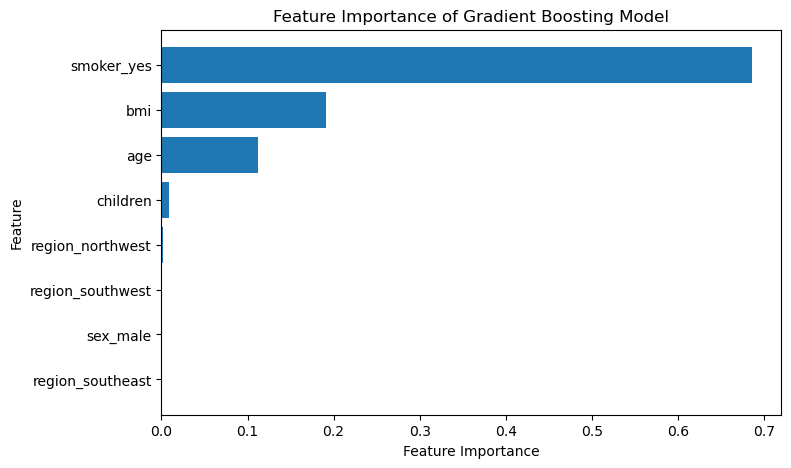

In [22]:
## Further feature engineering / feature selection
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance of Gradient Boosting Model")

plt.show()


Feature importance was extracted from the tuned Gradient Boosting model to determine the contribution of each feature towards predicting insurance charges. The graph shows that smoker, BMI, and age are the most influential features, while sex and the region variables contribute relatively less to the model. Since there are features with basically zero importance,during feature selection/feature engineering, I should remove those features and test if it improves my model.

In [23]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_reduced = X.drop(
    columns=[
        "sex_male",
        "region_northwest",
        "region_southwest",
        "region_southeast"
    ]
)

y = df["charges"]

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=200
)

gb_reduced = GradientBoostingRegressor(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=200
)

gb_reduced.fit(X_train_red, y_train_red)

pred_red = gb_reduced.predict(X_test_red)

print("Reduced Model")
print("MAE:", mean_absolute_error(y_test_red, pred_red))
print("R²:", r2_score(y_test_red, pred_red))

Reduced Model
MAE: 2457.7253629708325
R²: 0.8716452552662254


Feature selection was performed by removing features with near-zero importance (sex_male, region_northwest, region_southwest, and region_southeast). The model was retrained using the same tuned hyperparameters. The reduced-feature model achieved a slightly lower MAE (2457.73 vs. 2464.93) and a slightly higher R² (0.87165 vs. 0.87108) compared to the original tuned model. This indicates that these features contributed little to the prediction of insurance charges, and removing them simplified the model while maintaining, and slightly improving, predictive performance. Therefore, the reduced-feature model was selected as the final model.

In [ ]:
X = df.drop("charges", axis=1)
y = df["charges"]

X_reduced_v2 = X.drop(
    columns=[
        "region_northwest",
        "region_southwest",
        "region_southeast"
    ]
)

y = df["charges"]

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced_v2,
    y,
    test_size=0.2,
    random_state=200
)

gb_reduced = GradientBoostingRegressor(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=200
)

gb_reduced.fit(X_train_red, y_train_red)

pred_red = gb_reduced.predict(X_test_red)

print("Reduced Model v2 (with gender feature)")
print("MAE:", mean_absolute_error(y_test_red, pred_red))
print("R²:", r2_score(y_test_red, pred_red))

Reduced Model (with gender feature)
MAE: 2433.7907562515006
R²: 0.8723756355248232


Checked if sex_male feature is important as although in feature importance graph, it shows that sex_male has a very near 0 importance but it think that it could show something as gender could affect the price of insurance. After testing with the model with the sex_male but region removed.

The result shows that Reduced Model v2 has an improved MAE (from 2457.73 in the reduced model v1 and 2433.79 in the new reduced model v2) as well as a improved R² ( 0.87165 in reduced model v1 and from 0.87238 in the new reduced model v2)

This indicates that the model performed better with the sex_male feature and should be kept as it improved the MAE and R² values which shows that it predicted more accurately with this feature and should be kept instead of dropping the column.

In [25]:
##Save the best model for future streamlit app

joblib.dump(gb_reduced, "gradient_boosting.pkl")
joblib.dump(X_reduced_v2.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']